# Figures 2 and 3 — ML-FTLE validation on abrupt and periodic regime shifts

This notebook reproduces the **ML-FTLE results for datasets $\mathcal{D}_2$ and $\mathcal{D}_3$** described in the manuscript section *ML-FTLE Estimator ($\hat{\lambda}_{\mathrm{ML}}$)*.

These two datasets extend the validation beyond the gradual transient of Fig. 1 and test whether the same purely data-driven estimator can remain faithful under **more severe, non-stationary dynamical collapses**:

| Dataset | Physical scenario | Manuscript figure |
| ------ | ----------------- | ----------------- |
| $\mathcal{D}_2$ | Abrupt collapse from transient chaos to a fixed point | Fig. 2 |
| $\mathcal{D}_3$ | Transition from transient chaos to a stable periodic orbit | Fig. 3 |

The computational core is unchanged from Fig. 1: for each sliding window, the ML-FTLE proxy $\hat{\lambda}_{\mathrm{ML}}$ is estimated as the OLS slope of $\ln[\operatorname{GMAE}(h)]$ versus prediction horizon, using out-of-sample $k$-NN forecast errors. What changes here is the **type of macroscopic structural transition** the estimator must detect.

In the manuscript, $\mathcal{D}_2$ is used to show that the ML-FTLE can follow an **abrupt topological collapse** without prior model knowledge, while $\mathcal{D}_3$ demonstrates that the same proxy also distinguishes transient chaos from an eventual **non-chaotic periodic regime**, not only from a fixed point.

---

## Execution order

| Cell block | Purpose | Run order |
| ---------- | ------- | --------- |
| `c01`–`c04` | Imports, dataset discovery, core estimator, helper utilities | once |
| `c05_compute` | Full sliding-window ML-FTLE computation and CSV export | once per session |
| `c06_plot_signal_ftle` | Publication plot: scalar observable + ML-FTLE proxy | re-run freely |
| `c07_plot_diagnostics` | Optional diagnostics / development plots | re-run freely |

Output is written to each dataset's figure directory as `Fig_2_3.pdf` and to `ml_ftle.csv` within the corresponding `OUT_DIR`.



In [ ]:
import time, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import builtins
from pathlib import Path
from typing import Dict, List

warnings.filterwarnings('ignore')
print('Imports OK')


Imports OK


### `c02_params` — Dataset discovery

Discovers all parameter objects in `parameters/data_N.py` using `discover_all_params()`.

For the manuscript context, this notebook is intended primarily for:
- **`data_2`** → abrupt chaotic collapse to a fixed point (Fig. 2)
- **`data_3`** → chaotic-to-periodic transition (Fig. 3)

Each parameter object supplies the embedding dimension, delay, forecasting horizon, sliding-window length, smoothing width, output directory, and the physical stability threshold $\lambda_{\mathrm{thresh}}$ used to interpret the ML-FTLE curves.



In [ ]:
from parameters import discover_all_params
PARAM_SETS = discover_all_params()
print(f'{len(PARAM_SETS)} dataset(s) found.')


Discovered 3 parameter file(s) in d:\NLD_PROJECT\ML_FTLE\publication code\parameters:
  ✓  data_1.py  →  OUT_DIR=d:\NLD_PROJECT\ML_FTLE\publication code\data\data_1
  ✓  data_2.py  →  OUT_DIR=d:\NLD_PROJECT\ML_FTLE\publication code\data\data_2
  ✓  data_3.py  →  OUT_DIR=d:\NLD_PROJECT\ML_FTLE\publication code\data\data_3
3 dataset(s) found.


### `c03_core` — Import the ML-FTLE estimator

Imports `ftle_for_window()` from `core/ml_ftle.py`, which implements the manuscript's data-driven ML-FTLE procedure.

For every windowed segment, the estimator:
1. robustly rescales the scalar signal,
2. reconstructs delay-coordinate vectors,
3. performs chronological train/test splitting,
4. builds a local $k$-NN forecasting model,
5. measures the horizon-wise GMAE of out-of-sample prediction errors, and
6. assigns the OLS slope of $\ln[\operatorname{GMAE}(h)]$ as the local proxy $\hat{\lambda}_{\mathrm{ML}}$.

This is the same predictive-divergence mechanism used throughout the manuscript for equation-free finite-time Lyapunov estimation.



In [ ]:
from core.ml_ftle import ftle_for_window
print('ftle_for_window imported from core/ml_ftle.py')


ftle_for_window imported from core/ml_ftle.py


### `c04_helpers` — Data loading and sliding-window utilities

Defines lightweight helper functions for reading the scalar observable from CSV and constructing the center times of each sliding window.

These utilities are intentionally minimal: the scientific logic remains inside `ftle_for_window()`, while this cell only standardises how the time series is loaded and how window indices are aligned to physical time for plotting and CSV export.



In [ ]:
def load_csv(path, col=1):
    """Read (time, signal) from a CSV; col selects the observable column (default 1)."""
    df   = pd.read_csv(path)
    cols = df.columns.tolist()
    t    = df[cols[0]].values.astype(float)
    x    = df[cols[col]].values.astype(float)
    dt   = float(np.median(np.diff(t)))
    print(f'  CSV : {path}\n  Rows: {len(t)} | dt={dt:.4g}')
    return t, x, dt

def sliding_centers(t, L, step):
    """Return (idx_starts, window_center_times) for a sliding window of length L."""
    idx = np.arange(0, t.size - L + 1, step, dtype=int)
    return idx, t[idx + L // 2]

print('Helper functions defined.')


Helper functions defined.


### `c05_compute` — Sliding ML-FTLE scan *(run once per session)*

This is the main computation cell.

For each discovered dataset, the code:
1. loads the scalar observable from `P.ODE_CSV`,
2. pushes the required hyperparameters into `builtins` so that `ftle_for_window()` uses the correct configuration,
3. slides a temporal window of length `P.T_WINDOW_STEPS` across the signal with stride `P.T_STEP`,
4. computes one ML-FTLE estimate per window,
5. applies a centered median smoother to suppress shot-noise outliers while preserving the macroscopic transition shape, and
6. stores the resulting time series in both `all_compute[data_id]` and `ml_ftle.csv`.

In manuscript terms, this cell constructs the complete proxy trajectory $\hat{\lambda}_{\mathrm{ML}}(t)$ used to validate the method against the abrupt collapse in $\mathcal{D}_2$ and the chaos-to-periodic transition in $\mathcal{D}_3$.

Flat or degenerate windows are explicitly tracked through the `reason` field. This is useful for identifying segments where the observable has already collapsed into a near-stationary state and the predictive-divergence model is no longer informative.



In [ ]:


all_compute = {}   # data_id -> dict consumed by plot cells

for data_id, P in PARAM_SETS.items():
    print(f'\n{"="*62}\n  {data_id}\n{"="*62}')

    # Push hyper-parameters into builtins for ftle_for_window().
    for _k, _v in dict(
        EMB_DIM      = P.EMB_DIM,
        POINCARE_LAG = P.POINCARE_LAG,
        TAU          = P.POINCARE_LAG,
        KNN_NEIGH    = P.KNN_NEIGH,
        H_FTLE_MAX   = P.H_FTLE_MAX,
        HORIZON_MAX  = P.H_FTLE_MAX,
        TEST_RATIO   = getattr(P, 'TEST_RATIO', 0.30),
        LLE_THRESH   = P.LLE_THRESH,
        ODE_CSV      = P.ODE_CSV,
        OUT_DIR      = P.OUT_DIR,
    ).items():
        setattr(builtins, _k, _v)

    P.OUT_DIR.mkdir(parents=True, exist_ok=True)

    if not P.ODE_CSV.exists():
        print(f'  ⚠ {P.ODE_CSV} not found — run ode_solver first. Skipping.')
        continue

    t_ts, signal, dt_sig = load_csv(P.ODE_CSV, col=1)
    idx_starts, centers  = sliding_centers(t_ts, P.T_WINDOW_STEPS, P.T_STEP)
    total                = len(idx_starts)
    half_step            = P.T_STEP * dt_sig / 2   # half-width of one window span
    print(f'  Windows: {total}  L={P.T_WINDOW_STEPS}  step={P.T_STEP}  '
          f'EMB={P.EMB_DIM}  tau={P.POINCARE_LAG}')

    rows: List[Dict] = []
    t0 = time.time(); next_tick = 0.1

    for k, (s, tc) in enumerate(zip(idx_starts, centers)):
        seg = signal[s: s + P.T_WINDOW_STEPS]
        fv, _, _, meta = ftle_for_window(
            seg, dt_sig,
            m=P.EMB_DIM, k_neighbors=P.KNN_NEIGH, H_ftle=P.H_FTLE_MAX,
        )
        rows.append({
            'time': float(tc),
            'ftle': float(fv) if np.isfinite(fv) else 0.0,
            **{kk: vv for kk, vv in meta.items() if not isinstance(vv, list)},
        })

        frac = (k + 1) / total
        if frac >= next_tick or k == total - 1:
            wps = (k + 1) / max(time.time() - t0, 1e-9)
            rsn = meta.get('reason', '')
            print(f'  [{k+1:4d}/{total}] {frac*100:5.1f}%  '
                  f'FTLE={fv:+.5f}  valid_h={meta.get("n_valid_horizons",0):2d}  '
                  f'r2={meta.get("r2",0.0):.2f}  [{rsn:<24}]  {wps:.1f} w/s')
            next_tick += 0.1

    df = pd.DataFrame(rows)
    # Median rolling smoother — suppresses shot-noise while preserving regime shape.
    df['ftle_smooth'] = df['ftle'].rolling(
        P.SMOOTH_WINDOW, center=True, min_periods=5).median()

    out_csv = P.OUT_DIR / 'ml_ftle.csv'
    df.to_csv(out_csv, index=False)
    print(f'  Saved → {out_csv}')

    # Print breakdown of window outcomes.
    rc = df['reason'].value_counts().to_dict() if 'reason' in df.columns else {}
    print(f'  Normal (slope estimated)         : {rc.get("", 0):4d}')
    print(f'  Flat / fixed-point → FTLE=0      : {rc.get("flat_signal", 0):4d}')
    print(f'  Too few valid horizons → FTLE=0  : {rc.get("too_few_valid_horizons", 0):4d}')
    print(f'  Too short → FTLE=NaN             : {rc.get("too_short", 0):4d}')

    all_compute[data_id] = dict(
        P=P, t_ts=t_ts, signal=signal, dt_sig=dt_sig,
        idx_starts=idx_starts, centers=centers,
        half_step=half_step, df=df,
    )

print('\n✓ Compute complete.')



  data_1
  CSV : d:\NLD_PROJECT\ML_FTLE\publication code\data\data_1\csv_mkg\ode_trajectory.csv
  Rows: 6001 | dt=1
  Windows: 184  L=500  step=30  EMB=8  tau=5
  [  19/184]  10.3%  FTLE=+0.03041  valid_h=40  r2=0.88  [                        ]  19.5 w/s
  [  37/184]  20.1%  FTLE=+0.00847  valid_h=40  r2=0.37  [                        ]  19.8 w/s
  [  56/184]  30.4%  FTLE=+0.02039  valid_h=40  r2=0.84  [                        ]  20.0 w/s
  [  74/184]  40.2%  FTLE=+0.00787  valid_h=40  r2=0.76  [                        ]  19.9 w/s
  [  92/184]  50.0%  FTLE=-0.00143  valid_h=40  r2=0.02  [                        ]  20.0 w/s
  [ 111/184]  60.3%  FTLE=-0.00121  valid_h=40  r2=0.02  [                        ]  20.1 w/s
  [ 129/184]  70.1%  FTLE=-0.00089  valid_h=40  r2=0.01  [                        ]  20.2 w/s
  [ 148/184]  80.4%  FTLE=-0.00164  valid_h=40  r2=0.05  [                        ]  20.3 w/s
  [ 166/184]  90.2%  FTLE=-0.00180  valid_h=40  r2=0.04  [                        ]  2

## Plot cells

All cells below read from the cached `all_compute` dictionary produced by `c05_compute` and may be re-run independently.

This separation is useful during manuscript preparation: the computationally expensive ML-FTLE sweep is performed once, while figure styling, axis limits, labels, and export settings can be adjusted repeatedly without recomputing the underlying proxy series.



### `c06_plot_signal_ftle` — Manuscript figure for Figs. 2 and 3

Generates the two-panel publication figure used to present the ML-FTLE results for datasets $\mathcal{D}_2$ and $\mathcal{D}_3$.

#### Top panel — Scalar observable
The raw scalar time series $x(t)$ is shown directly. In the manuscript, this panel provides the visual evidence of the macroscopic regime shift:
- for **$\mathcal{D}_2$**, the chaotic oscillations collapse abruptly into a stationary state near $t \approx 3800$;
- for **$\mathcal{D}_3$**, the transient chaotic oscillations settle into a sustained periodic orbit near $t \approx 4700$.

Flat or fixed-point windows are shaded in silver to indicate intervals where the signal has already lost the local geometric variability required for meaningful divergence estimation.

#### Bottom panel — ML-FTLE proxy
Plots the smoothed ML-FTLE trajectory $\hat{\lambda}_{\mathrm{ML}}(t)$ on the same time axis as the scalar signal. The horizontal baseline at zero helps visualise the transition from chaotic to non-chaotic dynamics.

This panel corresponds directly to the manuscript interpretation:
- in **Fig. 2**, the proxy drops sharply as the attractor collapses and crosses the stability threshold essentially concurrently with the abrupt structural decay;
- in **Fig. 3**, the proxy remains strongly positive during transient chaos and then declines toward the non-chaotic regime as the system converges to periodic motion, with a slight lag attributable to the sliding-window forecast construction.

Together, these two panels demonstrate the main claim of this section of the manuscript: the ML-FTLE estimator can map **both abrupt and qualitative regime changes** onto the Lyapunov scale using only a scalar observable and without access to the governing equations.




✓ Figure saved → d:\NLD_PROJECT\ML_FTLE\publication code\data\data_1\Figure\Fig_2_3.pdf


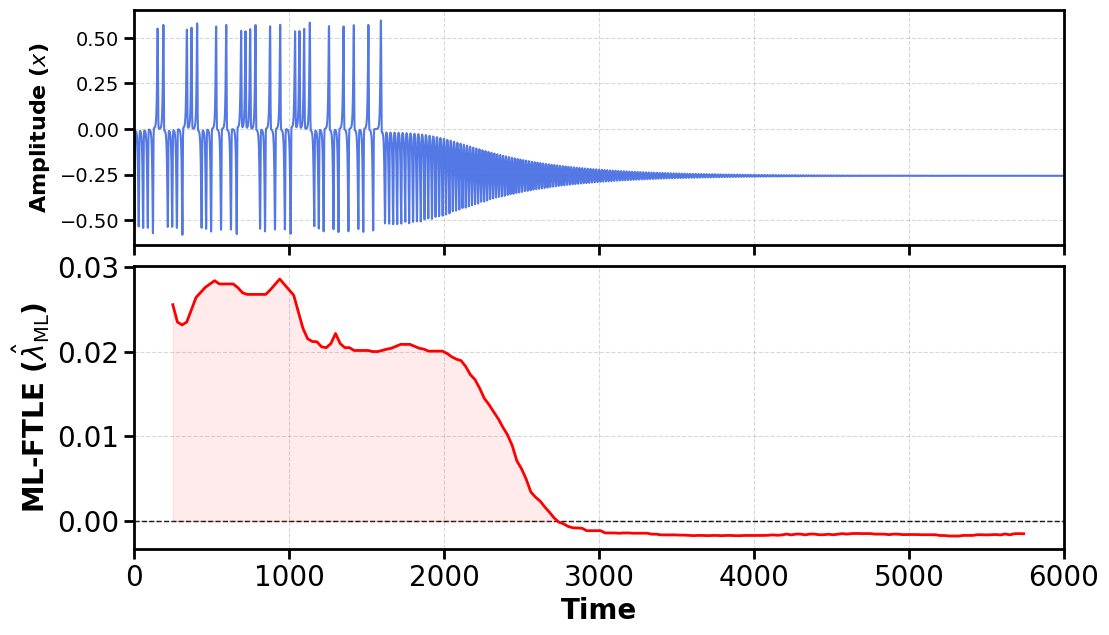


✓ Figure saved → d:\NLD_PROJECT\ML_FTLE\publication code\data\data_2\Figure\Fig_2_3.pdf


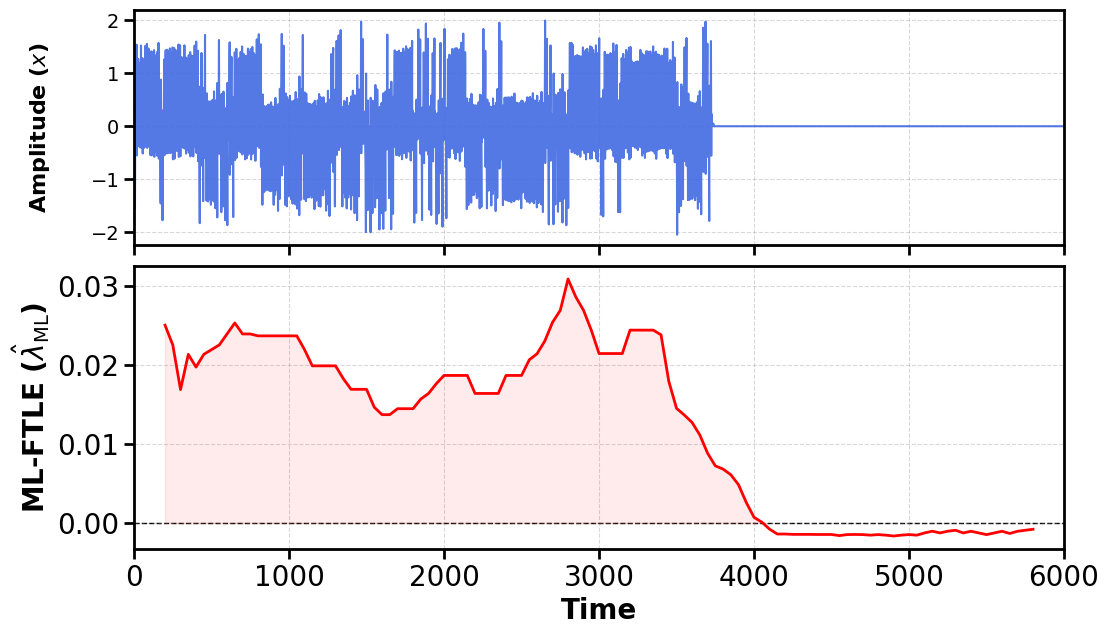


✓ Figure saved → d:\NLD_PROJECT\ML_FTLE\publication code\data\data_3\Figure\Fig_2_3.pdf


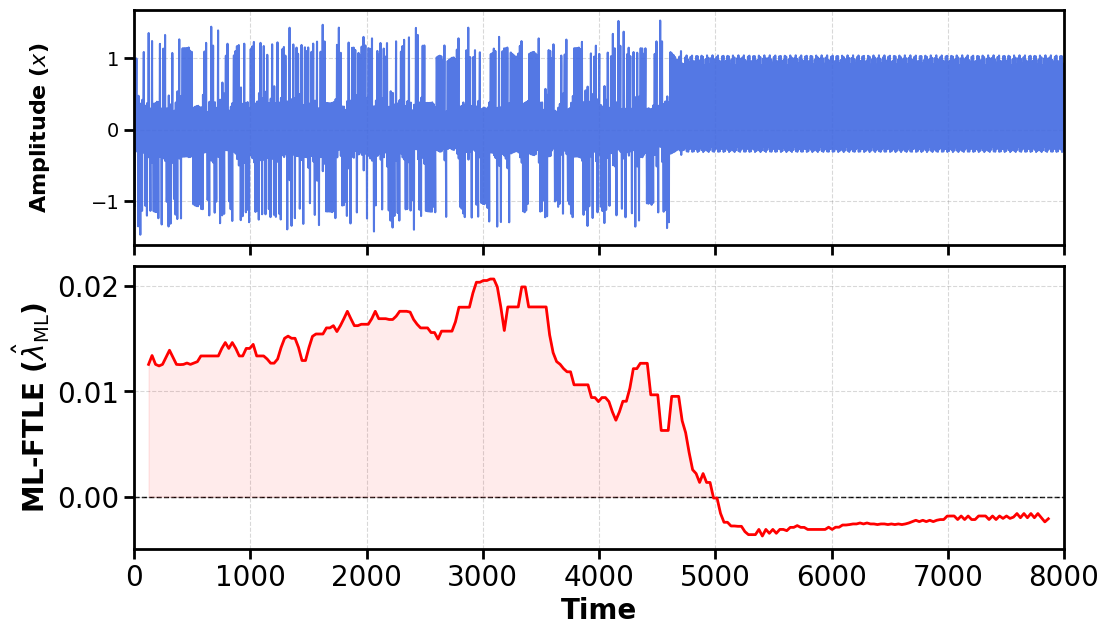

In [ ]:


assert 'all_compute' in globals(), "Run c05_compute first."

plt.rcParams.update({
    'font.family':       'sans-serif',
    'axes.linewidth':    2.0,
    'xtick.major.width': 2.0,
    'ytick.major.width': 2.0,
    'xtick.major.size':  7,
    'ytick.major.size':  7,
})

for data_id, C in all_compute.items():
    P          = C['P']
    t_ts       = C['t_ts']
    signal     = C['signal']
    df         = C['df']
    half_step  = C['half_step']
    thresh     = P.LLE_THRESH

    # Collect flat-window centre times for shading.
    flat_times = (
        df.loc[df['reason'] == 'flat_signal', 'time'].values
        if 'reason' in df.columns else np.array([])
    )

    fig, (ax_sig, ax_ftle) = plt.subplots(
        2, 1,
        figsize=(12, 7),
        sharex=True,
        gridspec_kw={'height_ratios': [1, 1.2], 'hspace': 0.08},
    )

    # ── Top panel: scalar observable ─────────────────────────────────────────
    for t_c in flat_times:
        ax_sig.axvspan(t_c - half_step, t_c + half_step,
                       color='silver', alpha=0.35, linewidth=0, zorder=0)

    ax_sig.plot(t_ts, signal, color='royalblue', lw=1.5, alpha=0.9, zorder=2)
    ax_sig.set_ylabel('Amplitude ($x$)', fontsize=16, fontweight='bold')
    ax_sig.set_xlim(t_ts.min(), t_ts.max())
    ax_sig.grid(True, alpha=0.3, ls='--', color='gray')
    ax_sig.tick_params(labelsize=14, length=7, width=2.0)
    # Inside your plotting function or loop:
    """
    ax_sig.text(7950, 1.2, '(a)', 
            fontsize=20, 
            fontweight='bold', 
            va='bottom', 
            ha='right')
    """
    for sp in ax_sig.spines.values():
        sp.set_linewidth(2.0)
    # Hide x-tick labels on top panel (shared axis).
    plt.setp(ax_sig.get_xticklabels(), visible=False)

    # ── Bottom panel: ML-FTLE proxy ───────────────────────────────────────────
    for t_c in flat_times:
        ax_ftle.axvspan(t_c - half_step, t_c + half_step,
                        color='silver', alpha=0.35, linewidth=0, zorder=0)
    if len(flat_times):
        ax_ftle.axvspan(0, 0, color='silver', alpha=0.5,
                        label='Flat / fixed-point', zorder=0)   # legend proxy

    ax_ftle.plot(df['time'], df['ftle_smooth'],
                 color='red', lw=2.0, zorder=3,
                 label=r'$\hat{\lambda}_{\mathrm{ML}}$')
    ax_ftle.fill_between(
        df['time'], df['ftle_smooth'], 0,
        where=(df['ftle_smooth'].fillna(0) > 0),
        color='red', alpha=0.08, zorder=2,
    )
    ax_ftle.axhline(0, lw=1.0, ls='--', color='black', zorder=1)

    ax_ftle.set_xlabel('Time', fontsize=20, fontweight='bold')
    ax_ftle.set_ylabel(r'ML-FTLE ($\hat{\lambda}_{\mathrm{ML}}$)',
                       fontsize=20, fontweight='bold')
    """
    ax_ftle.text(7950, 0.018, '(b)', 
            fontsize=20, 
            fontweight='bold', 
            va='bottom', 
            ha='right')
    """
    ax_ftle.grid(True, alpha=0.3, ls='--', color='gray')
    ax_ftle.tick_params(labelsize=20, length=7, width=2.0)
    for sp in ax_ftle.spines.values():
        sp.set_linewidth(2.0)

    fig.align_ylabels([ax_sig, ax_ftle])
    fig.tight_layout()

    # ── 4. Save ──────────────────────────────────────────────────────────────
    fig_dir  = P.OUT_DIR / 'Figure'
    fig_dir.mkdir(parents=True, exist_ok=True)
    out_path = fig_dir / f'Fig_2_3.pdf'
    plt.savefig(out_path, dpi=1200, bbox_inches='tight')
    print(f'\n✓ Figure saved → {out_path}')
    plt.show()
    plt.close(fig)
